# Linear Regression và dự đoán số nội dung trên Netflix

Mục tiêu:

- Huấn luyện mô hình Linear Regression bằng toàn bộ dữ liệu 2011–2020.
- Dự báo số nội dung được thêm từ 01/2021 đến 09/2021.
- Đối chiếu dự báo với dữ liệu thực tế 9 tháng năm 2021.
- Đánh giá mô hình bằng MAE và RMSE.
- Trình bày hai biểu đồ riêng: xu hướng và residual plot.


## Import thư viện

In [76]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

from sklearn.linear_model import LinearRegression

## Đọc dữ liệu

In [77]:
ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent

file_path = ROOT / "data" / "normalized" / "fact_monthly_addition.csv"

df = pd.read_csv(file_path)

df["month"] = pd.to_datetime(
    df["date_key"].astype(str),
    format="%Y%m%d",
)

df.head()

,date_key,monthly_additions,month_index,month
0,20110101,0,0,2011-01-01
1,20110201,0,1,2011-02-01
2,20110301,0,2,2011-03-01
3,20110401,0,3,2011-04-01
4,20110501,1,4,2011-05-01


## Kiểm tra dữ liệu

In [78]:
print("Số tháng: ", len(df))
print("Từ tháng: ", df["month"].min())
print("Đến tháng: ", df["month"].max())
print("Tổng số nội dung: ", df["monthly_additions"].sum())

Số tháng:  120
Từ tháng:  2011-01-01 00:00:00
Đến tháng:  2020-12-01 00:00:00
Tổng số nội dung:  7294


## Vẽ chuỗi dữ liệu gốc

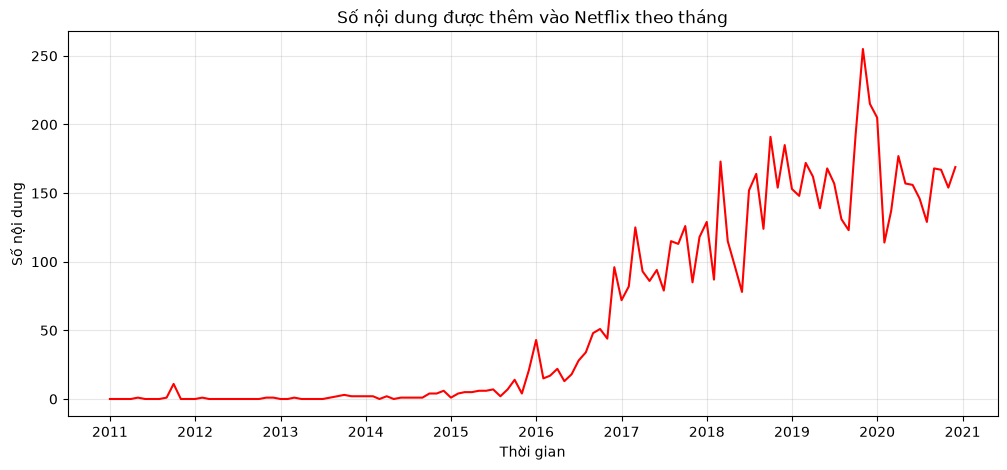

In [79]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["month"],
    df["monthly_additions"],
    color="red"
)

plt.title("Số nội dung được thêm vào Netflix theo tháng")
plt.xlabel("Thời gian")
plt.ylabel("Số nội dung")
plt.grid(alpha=0.3)
plt.show()

## Huấn luyện mô hình trên toàn bộ dữ liệu 2011–2020

In [86]:
final_model = LinearRegression()

final_model.fit(
    df[["month_index"]],
    df["monthly_additions"]
)

df["fitted"] = final_model.predict(
    df[["month_index"]]
)

df["residual"] = (
    df["monthly_additions"] - df["fitted"]
)

training_mae = df["residual"].abs().mean()

print("Hệ Beta 1:", final_model.coef_[0])
print("Hệ Beta 0:", final_model.intercept_)
print("MAE:", training_mae)


Hệ Beta 1: 1.8082991874435725
Hệ Beta 0: -46.810468319559234
MAE: 26.836197073870874


## Forecast 9 tháng


In [81]:
forecast_horizon = 9
first_future_index = df["month_index"].max() + 1

future = pd.DataFrame({
    "month_index": range(
        first_future_index,
        first_future_index + forecast_horizon
    )
})

future["month"] = pd.date_range(
    start=df["month"].max() + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)

future["forecast"] = final_model.predict(
    future[["month_index"]]
)

future["forecast_rounded"] = (
    future["forecast"]
    .round()
    .astype(int)
)

future


,month_index,month,forecast,forecast_rounded
0,120,2021-01-01,170.185434,170
1,121,2021-02-01,171.993733,172
2,122,2021-03-01,173.802033,174
3,123,2021-04-01,175.610332,176
4,124,2021-05-01,177.418631,177
5,125,2021-06-01,179.226930,179
6,126,2021-07-01,181.035229,181
7,127,2021-08-01,182.843528,183
8,128,2021-09-01,184.651828,185


## Dữ liệu thực tế và chỉ số đánh giá


In [82]:
actual_path = ROOT / "data" / "processed" / "netflix_titles.csv"
actual_source = pd.read_csv(
    actual_path,
    usecols=["date_added"]
)
actual_source["date_added"] = pd.to_datetime(
    actual_source["date_added"],
    errors="coerce"
)

actual_2021 = (
    actual_source[
        actual_source["date_added"].between(
            "2021-01-01",
            "2021-09-30"
        )
    ]
    .assign(
        month=lambda data: (
            data["date_added"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )
    )
    .groupby("month")
    .size()
    .rename("actual")
    .reset_index()
)

comparison = future.merge(
    actual_2021,
    on="month",
    how="left",
    validate="one_to_one"
)

if comparison["actual"].isna().any():
    raise ValueError("Thiếu dữ liệu thực tế trong giai đoạn 01/2021–09/2021")

# e_i = y_i - y_hat_i
comparison["residual"] = (
    comparison["actual"] - comparison["forecast"]
)

mae = comparison["residual"].abs().mean()
rmse = (comparison["residual"].pow(2).mean()) ** 0.5

metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "value": [mae, rmse]
})

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
comparison[["month", "actual", "forecast_rounded", "residual"]]


MAE: 36.78
RMSE: 44.76


,month,actual,forecast_rounded,residual
0,2021-01-01,132,170,-38.185434
1,2021-02-01,109,172,-62.993733
2,2021-03-01,112,174,-61.802033
3,2021-04-01,188,176,12.389668
4,2021-05-01,132,177,-45.418631
5,2021-06-01,207,179,27.773070
6,2021-07-01,257,181,75.964771
7,2021-08-01,178,183,-4.843528
8,2021-09-01,183,185,-1.651828


## Hai biểu đồ chẩn đoán và dự báo


### 1. Xu hướng và đường hồi quy: 01/2011–09/2021


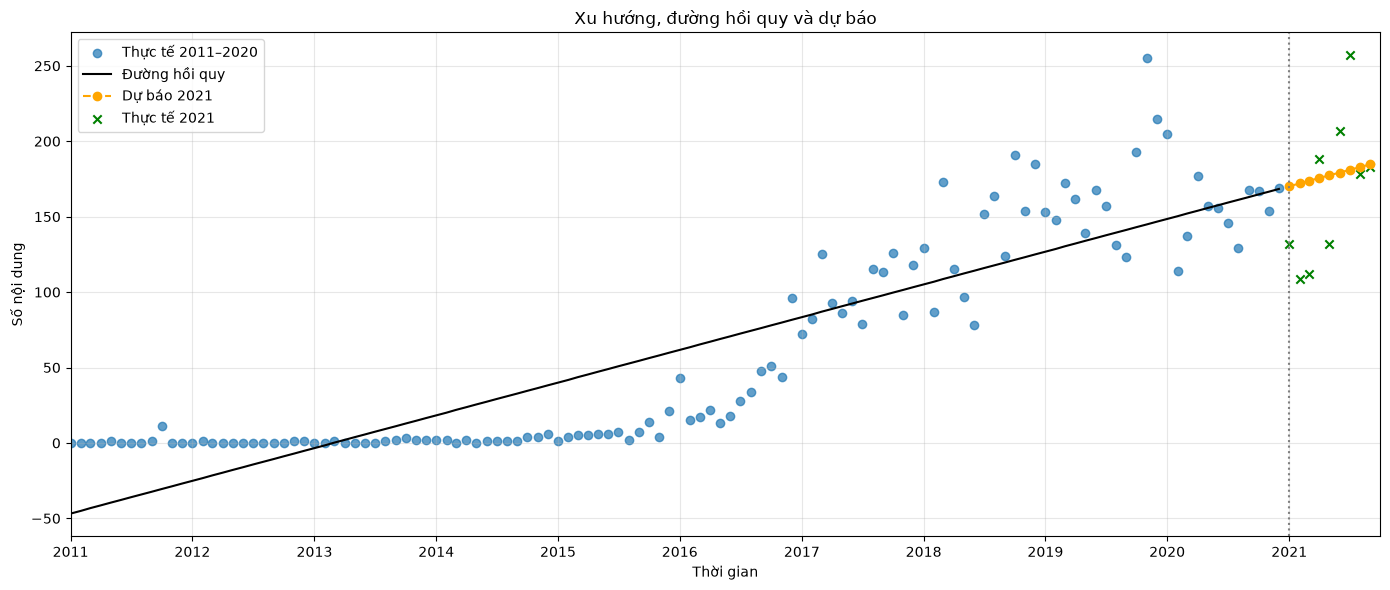

In [83]:
output_dir = ROOT / "data" / "model_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 6))

# Dữ liệu và đường hồi quy của tập train
plt.scatter(
    df["month"],
    df["monthly_additions"],
    label="Thực tế 2011–2020",
    alpha=0.7
)
plt.plot(
    df["month"],
    df["fitted"],
    label="Đường hồi quy",
    color="black"
)

# Dự báo và dữ liệu thực tế năm 2021
plt.plot(
    comparison["month"],
    comparison["forecast"],
    "o--",
    label="Dự báo 2021",
    color="orange"
)
plt.scatter(
    comparison["month"],
    comparison["actual"],
    label="Thực tế 2021",
    color="green",
    marker="x"
)

plt.axvline(
    pd.Timestamp("2021-01-01"),
    color="gray",
    linestyle=":"
)

plt.title("Xu hướng, đường hồi quy và dự báo")
plt.xlabel("Thời gian")
plt.ylabel("Số nội dung")
plt.xlim(pd.Timestamp("2011-01-01"), pd.Timestamp("2021-09-30"))
plt.xticks(
    pd.date_range("2011-01-01", "2021-01-01", freq="YS"),
    range(2011, 2022)
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_dir / "trend_and_data_9_months.png",
    dpi=180
)
plt.show()


### 2. Residual plot: tập train 01/2011–12/2020


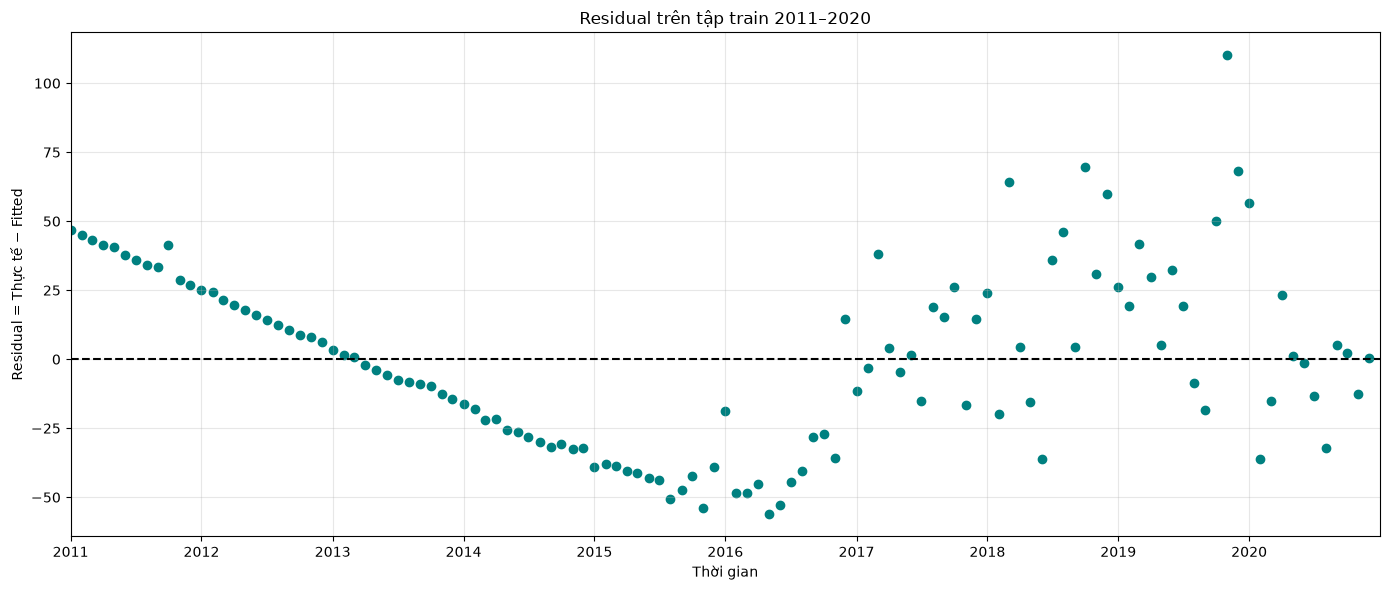

In [84]:
plt.figure(figsize=(14, 6))

plt.scatter(
    df["month"],
    df["residual"],
    color="teal"
)
plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Residual trên tập train 2011–2020")
plt.xlabel("Thời gian")
plt.ylabel("Residual = Thực tế − Fitted")
plt.xlim(pd.Timestamp("2011-01-01"), pd.Timestamp("2020-12-31"))
plt.xticks(
    pd.date_range("2011-01-01", "2020-01-01", freq="YS"),
    range(2011, 2021)
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_dir / "residual_plot.png",
    dpi=180
)
plt.show()


In [85]:
future[
    ["month", "month_index", "forecast", "forecast_rounded"]
].to_csv(
    output_dir / "forecast_9_months.csv",
    index=False
)

comparison[
    ["month", "actual", "forecast", "forecast_rounded", "residual"]
].to_csv(
    output_dir / "forecast_vs_actual_2021.csv",
    index=False
)

actual_predicted_error = comparison[
    ["month", "actual", "forecast", "residual"]
].rename(columns={
    "forecast": "predicted",
    "residual": "error"
})

actual_predicted_error.to_csv(
    output_dir / "actual_predicted_error_2021.csv",
    index=False
)

metrics.to_csv(
    output_dir / "model_metrics.csv",
    index=False
)


## Nhận xét

- Mô hình được huấn luyện trên 120 tháng từ 01/2011 đến 12/2020 và dự báo 9 tháng từ 01/2021 đến 09/2021.
- Biểu đồ xu hướng nối dữ liệu train, đường hồi quy và giai đoạn dự báo; dữ liệu thực tế 2021 được đánh dấu riêng để đối chiếu.
- Residual plot dùng toàn bộ tập train 2011–2020 với công thức $e_i = y_i - \hat{y}_i$ để kiểm tra hình dạng sai số của mô hình.
- MAE và RMSE được tính riêng trên dữ liệu thực tế 01/2021–09/2021 để đánh giá sai số dự báo ngoài mẫu.
- Linear Regression chỉ mô tả xu hướng tuyến tính và chưa xử lý mùa vụ hoặc biến động bất thường.
